# InterScale Pipeline: Combined model

1. Local Model = GCN
2. Global Model = Self-attention transformer

Data: Melton et. al. 

In [1]:
import scanpy as sc
import numpy as np

import InterScale as interscale
from InterScale.config import load_config
#from graph_transformer_long_range_niches.pp import split_adata
from InterScale.tl import prepare_geome_dataset, check_and_update_cfg
from InterScale.geome_dataloader import GraphAnnDataModule

/Users/sara.jimenez/miniconda3/envs/GT_long_range/lib/python3.11/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/Users/sara.jimenez/miniconda3/envs/GT_long_range/lib/python3.11/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/Users/sara.jimenez/miniconda3/envs/GT_long_range/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readth

In [2]:
CFG_PATH_REG = "/Users/sara.jimenez/Documents/Projects/Long_range_interactions/configs/configs/melton25_combined.yaml"

## 0. Load and prepare data

In [3]:
cfg = load_config(CFG_PATH_REG)
cfg

CfgNode({'wandb': CfgNode({'use': False, 'project_name': 'GTLongRange_CosmXPancreas'}), 'model': CfgNode({'n_embed': 16, 'local_component': CfgNode({'name': 'GCN', 'load': None, 'parameters': CfgNode({'hidden_dim': 256, 'num_layers': 2, 'dropout_local': 0.1})}), 'global_component': CfgNode({'name': 'self-attn-transformer', 'load': None, 'parameters': CfgNode({'n_heads': 4, 'dim_feedforward': 256, 'dropout_global': 0.3, 'activation_func': 'relu', 'num_layers': 2, 'max_seq_len': 3000, 'long_range_attention': False})}), 'save': None, 'loss': None, 'decoder': CfgNode({'type': 'linear', 'hidden_dims': [256, 128], 'dropout_decoder': 0.1})}), 'optim': CfgNode({'accelerator': 'auto', 'lr': 0.001, 'lr_scheduler': 'CosineWarmupScheduler', 'lr_warmup': 20, 'lr_max_epochs': 100, 'wd': 0.0001, 'loss': 'MSELoss', 'seed': 44, 'cross_corr': 'cell', 'n_epochs': 100, 'early_stopping': True}), 'dataset': CfgNode({'h5ad_data': '/Users/sara.jimenez/Documents/Projects/Long_range_interactions/data/cosmx_panc

In [4]:
adata = sc.read_h5ad(cfg.dataset.h5ad_data)
adata

AnnData object with n_obs × n_vars = 386727 × 979
    obs: 'fov', 'Area', 'AspectRatio', 'CenterX_global_px', 'CenterY_global_px', 'Width', 'Height', 'Mean.MembraneStain', 'Max.MembraneStain', 'Mean.PanCK', 'Max.PanCK', 'Mean.GCG', 'Max.GCG', 'Mean.CD3', 'Max.CD3', 'Mean.DAPI', 'Max.DAPI', 'cell_ID', 'condition', 'slide', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_NegPrb', 'log1p_total_counts_NegPrb', 'pct_counts_NegPrb', 'n_genes', 'cell_type_coarse', 'CellTypes_max', 'slide_fov', 'slide_condition', 'split', 'split_0', 'split_1', 'split_2', 'globalX', 'globalY', 'sliding_window_square', 'sliding_window_h', 'sliding_window_v'
    obsm: 'X_pca', 'X_umap', 'spatial', 'spatial_fov'
    layers: 'counts'

Remove cells with zero expression across all genes. Gives error for pearson correlation.

In [5]:
zero_expression_cells = np.array((adata.X.sum(axis=1) == 0)).flatten()
print(f"Nr. of zero expression cells: {zero_expression_cells.sum()}")
nonzero_cells = np.array((adata.X.sum(axis=1) != 0)).flatten()
adata = adata[nonzero_cells].copy()

Nr. of zero expression cells: 0


In [6]:
import pandas as pd
# Creating a DataFrame from 'split', 'fov', and 'condition'
df = adata.obs[['split', 'fov', 'condition']]
value_counts = pd.DataFrame(df.values, columns=df.columns).value_counts()
print(value_counts)

split  fov  condition
test   11   T1D          7627
       8    T1D          7360
       13   T1D          7313
       25   T1D          7237
       9    T1D          6955
                         ... 
train  21   ND           4053
       3    T1D          4000
       5    T1D          3895
       11   T1D          3493
       14   ND           2321
Name: count, Length: 71, dtype: int64


## 1. Data setup

We need to specify:

- `prediction_task`: Prediction task can either be classification or regression
- `prediction_level`: Which level the predictions should be performed on: either (1) tissue label, e.i. condition (`graph`), (2) node label (`node`) for cell type or niche prediciton, or (3) GEX prediction.

Additionally, we define dataset specific keys: 
- `prediction_obs`: Label in `adata.obs` to be predicted. Only required for classification tasks.
- `layer_key`: Defines which GEX matrix to retrieve from `adata.layer`
- `sample_key`: `adata.obs` used to split the samples into PyG Data objects
- `group_label`: Optional: only if we have a `adata.obs` group that we want to stratify during sampling

In [7]:
PREDICTION_TASK = 'regression'
PREDICTION_LEVEL = 'node'

#prediction_obs = 'condition'
layer_key = None #'log1p_norm'
sample_key = ["sliding_window_square", "sliding_window_v"]
group_label = 'condition'

In [8]:
cfg = check_and_update_cfg(
    cfg, 
    prediction_task = PREDICTION_TASK, 
    prediction_level = PREDICTION_LEVEL, 
    layer_key = layer_key, 
    sample_key = sample_key, 
    #prediction_obs = prediction_obs
)

Update sample key (from '['sliding_window_square', 'sliding_window_v']' to '['sliding_window_square', 'sliding_window_v']')
Update group label (from 'condition' to 'None')


In [9]:
interscale.model.CombinedModel._setup_anndata(
    adata = adata, 
    prediction_task = PREDICTION_TASK, 
    layer_key = layer_key, 
    sample_key_list = sample_key, 
    #prediction_obs = prediction_obs, 
    group_key = group_label
)

/Users/sara.jimenez/miniconda3/envs/GT_long_range/lib/python3.11/site-packages/scvi/data/fields/_base_field.py:63: UserWarning: adata.X does not contain unnormalized count data. Are you sure this is what you want?
  self.validate_field(adata)


Anndata setup with scvi-tools version 1.3.2.

     Summary Statistics     
┏━━━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃ Summary Stat Key ┃ Value ┃
┡━━━━━━━━━━━━━━━━━━╇━━━━━━━┩
│   n_group_key    │   2   │
│  n_sample_key_0  │  596  │
│  n_sample_key_1  │  803  │
│       n_x        │  979  │
└──────────────────┴───────┘

                  Data Registry                   
┏━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Registry Key ┃       scvi-tools Location       ┃
┡━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│  group_key   │  adata.obs['_scvi_group_key']   │
│ sample_key_0 │ adata.obs['_scvi_sample_key_0'] │
│ sample_key_1 │ adata.obs['_scvi_sample_key_1'] │
│      x       │             adata.X             │
└──────────────┴─────────────────────────────────┘

                         sample_key_0 State Registry                         
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃          Source Location           ┃   Categories   ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['sliding_window_square'] │  1_4_window_0  │          0          │
│                                    │  1_8_window_0  │          1          │
│                                    │ 1_10_window_0  │          2          │
│                                    │ 1_11_window_0  │          3          │
│                                    │ 1_16_window_0  │          4          │
│                                    │ 1_18_window_0  │          5          │
│                                    │ 1_19_window_0  │          6          │
│                                    │ 1_22_window_0  │          7          │
│                                    │ 1_23_window_0  │          8          │
│                                    │ 1_24_window_0  │          9          │
│                                    │  2_1_window_0  │         10          │
│                                    │  2_2_window_0  │         11          │
│                                    │  2_5_window_0  │         12          │
│                                    │  2_7_window_0  │         13          │
│                                    │  2_9_window_0  │         14          │
│                                    │ 2_10_window_0  │         15          │
│                                    │ 2_11_window_0  │         16          │
│                                    │ 2_12_window_0  │         17          │
│                                    │ 2_17_window_0  │         18          │
│                                    │ 2_20_window_0  │         19          │
│                                    │ 2_22_window_0  │         20          │
│                                    │  3_1_window_0  │         21          │
│                                    │  3_4_window_0  │         22          │
│                                    │  3_5_window_0  │         23          │
│                                    │  3_7_window_0  │         24          │
│                                    │  3_8_window_0  │         25          │
│                                    │ 3_10_window_0  │         26          │
│                                    │ 3_12_window_0  │         27          │
│                                    │ 3_13_window_0  │         28          │
│                                    │ 3_14_window_0  │         29          │
│                                    │ 3_20_window_0  │         30          │
│                                    │  1_1_window_1  │         31          │
│                                    │  1_2_window_1  │         32          │
│                                    │  1_4_window_1  │         33          │
│                                    │  1_7_window_1  │         34          │
│                                    │  1_8_window_1  │         35          │
│                                    │  1_9_window_1  │         36          │
│                                    │ 1_10_window_1  │         37          │
│                                    │ 1_12_window_1  │         38          │
│                                    │ 1_16_window_1  │         39          │
│                                    │ 1_17_window_1  │         40          │
│                                    │ 1_18_window_1  │         41          │
│                                    │ 1_19_window_1  │         42          │
│                                    │ 1_20_window_1  │         43          │
│                                    │ 1_21_window_1  │         44          │
│                                    │ 1_22_window_1  │         45          │
│                                    │ 1_23_window_1  │         46          │
│                     

                      sample_key_1 State Registry                       
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃        Source Location        ┃   Categories   ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['sliding_window_v'] │  1_2_window_0  │          0          │
│                               │  1_3_window_0  │          1          │
│                               │  1_4_window_0  │          2          │
│                               │  1_5_window_0  │          3          │
│                               │  1_8_window_0  │          4          │
│                               │ 1_10_window_0  │          5          │
│                               │ 1_11_window_0  │          6          │
│                               │ 1_12_window_0  │          7          │
│                               │ 1_16_window_0  │          8          │
│                               │ 1_18_window_0  │          9          │
│                               │ 1_19_window_0  │         10          │
│                               │ 1_20_window_0  │         11          │
│                               │ 1_21_window_0  │         12          │
│                               │ 1_22_window_0  │         13          │
│                               │ 1_23_window_0  │         14          │
│                               │ 1_24_window_0  │         15          │
│                               │  2_1_window_0  │         16          │
│                               │  2_2_window_0  │         17          │
│                               │  2_5_window_0  │         18          │
│                               │  2_6_window_0  │         19          │
│                               │  2_7_window_0  │         20          │
│                               │  2_8_window_0  │         21          │
│                               │ 2_11_window_0  │         22          │
│                               │ 2_14_window_0  │         23          │
│                               │ 2_16_window_0  │         24          │
│                               │ 2_17_window_0  │         25          │
│                               │ 2_19_window_0  │         26          │
│                               │ 2_20_window_0  │         27          │
│                               │ 2_22_window_0  │         28          │
│                               │  3_1_window_0  │         29          │
│                               │  3_3_window_0  │         30          │
│                               │  3_5_window_0  │         31          │
│                               │  3_6_window_0  │         32          │
│                               │  3_7_window_0  │         33          │
│                               │  3_8_window_0  │         34          │
│                               │  3_9_window_0  │         35          │
│                               │ 3_10_window_0  │         36          │
│                               │ 3_12_window_0  │         37          │
│                               │ 3_13_window_0  │         38          │
│                               │ 3_15_window_0  │         39          │
│                               │ 3_20_window_0  │         40          │
│                               │ 3_22_window_0  │         41          │
│                               │ 3_23_window_0  │         42          │
│                               │ 3_24_window_0  │         43          │
│                               │ 3_25_window_0  │         44          │
│                               │  1_1_window_1  │         45          │
│                               │  1_2_window_1  │         46          │
│                               │  1_7_window_1  │         47          │
│                               │  1_9_window_1  │         48          │
│                               │ 1_10_window_1  │         49          │
│                               │ 1_12_window_1  │        

                  group_key State Registry                   
┏━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃    Source Location     ┃ Categories ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['condition'] │     ND     │          0          │
│                        │    T1D     │          1          │
└────────────────────────┴────────────┴─────────────────────┘

## 2. Model setup

In [10]:
model = interscale.model.CombinedModel(
    adata,
    cfg = cfg
)

/home/aih/sara.jimenez/miniconda3/envs/interscale/lib/python3.11/site-packages/torch/nn/modules/transformer.py:282: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")


In [11]:
model._model_summary_string

'regression model for node prediction. \nCombined Module: \nLocal Module: GCN Local Component: \nn_layers: 2, \nn_hidden: 256, \nn_embed: 16, \ndropout_local: 0.1\nGlobal Module: Transformer Encoder Global Component: \nmax_seq_len: 4299, \nn_heads: 4, \nact_func: relu, \nnum_layers: 2, \n\n'

## 3. Training

In [12]:
#split_adata(adata, split_obs='sample', val_size=cfg.dataset.val_size, test_size=cfg.dataset.test_size, seed = cfg.optim.seed, stratify_groups = cfg.dataset.group_label)
pyg_data_list, _ = prepare_geome_dataset(adata, cfg)
dm = GraphAnnDataModule(datas=pyg_data_list, 
                           num_workers=1, 
                           batch_size=int(cfg.dataset.batch_size), 
                           pct_mask_nodes=cfg.dataset.pct_mask_nodes,
                           learning_type="node")

Split key split already exists in adata.obs


In [13]:
cfg.dataset

CfgNode({'h5ad_data': '/lustre/groups/ml01/projects/2024_spatial_long_range_GT_francesca.drummer/data/legnini23.h5ad', 'name': 'legnini23', 'description': '', 'prediction_task': 'regression', 'prediction_obs': None, 'prediction_level': 'node', 'layer_key': 'log1p_norm', 'sample_key': ['sample'], 'group_label': None, 'split_key': 'split', 'spatial_neigbors_kwargs': CfgNode({'radius': 200, 'coord_type': 'generic', 'library_key': 'sample', 'n_neighs': 6}), 'batch_size': 3, 'train_size': 0.7, 'val_size': 0.2, 'test_size': 0.1, 'num_features': -1, 'num_classes': -1, 'stratify_group': None, 'pct_mask_nodes': 0.3, 'segmentation_robustness': None})

In [15]:
# for now training only works with datamodule. TODO: Add DataSplitter for datamodule independent training.
model.train(max_epochs = 100, 
            datamodule = dm,
            #batch_size=int(cfg.dataset.batch_size),
            #train_size=int(cfg.dataset.train_size),
            #validation_size=int(cfg.dataset.val_size),
            early_stopping = True)

[rank: 0] Seed set to 44
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


Steps per epoch 4
cross-cell per gene correlation metrics


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
You are using a CUDA device ('NVIDIA A100-PCIE-40GB MIG 3g.20gb') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
/home/aih/sara.jimenez/miniconda3/envs/interscale/lib/python3.11/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:751: Checkpoint directory /ictstr01/groups/ml01/workspace/sara.jimenez/InterScale/GT-long-range-niches/docs/notebooks/lightning_logs/version_31155799/checkpoints exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [MIG-c51c82f2-7e04-56a8-8b74-4211c9821715]

  | Name          | Type                | Params | Mode 
--------------------------------------------------------------
0 | module        | CombinedMo

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│   val_cosine_similarity   │     0.871412456035614     │
│         val_loss          │    0.15230804681777954    │
│          val_mse          │    0.3449743986129761     │
│     val_pearson_corr      │    0.08169793337583542    │
│          val_r2           │    -2.2650363445281982    │
└───────────────────────────┴───────────────────────────┘

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [MIG-c51c82f2-7e04-56a8-8b74-4211c9821715]
SLURM auto-requeueing enabled. Setting signal handlers.
/home/aih/sara.jimenez/miniconda3/envs/interscale/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:433: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=3` in the `DataLoader` to improve performance.


on_test_epoch_end 65


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│  test_cosine_similarity   │    0.9100328087806702     │
│         test_loss         │    0.12454269081354141    │
│         test_mse          │    0.2719878852367401     │
│     test_pearson_corr     │    0.11438571661710739    │
│          test_r2          │    -3.415044069290161     │
└───────────────────────────┴───────────────────────────┘


Early stopping triggered at epoch 64
Best val_mse: 0.3487


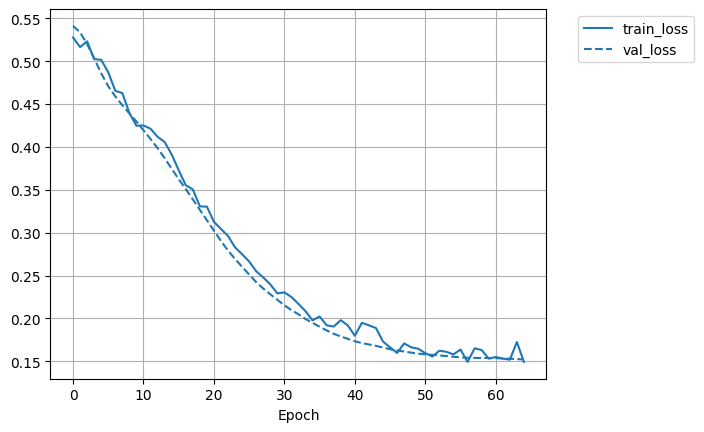

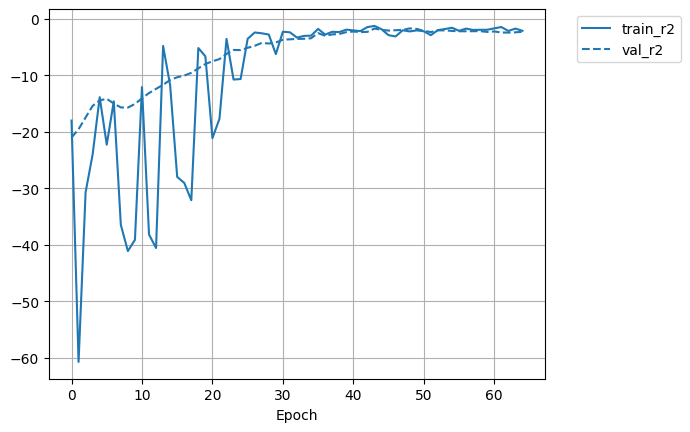

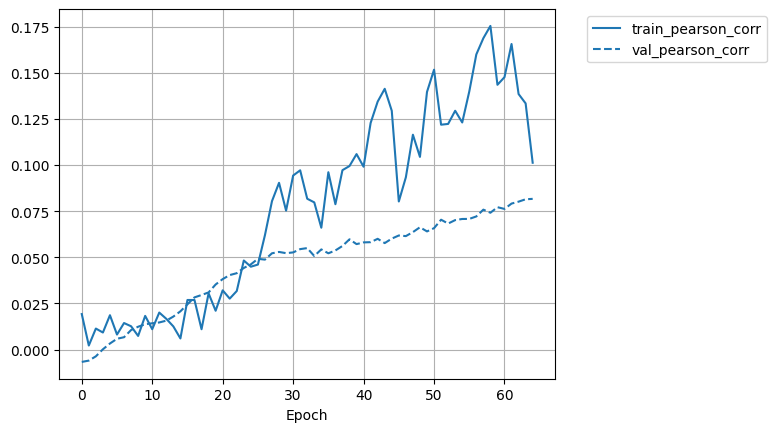

In [16]:
model.history_.plot_history(subset_term = 'loss')
model.history_.plot_history(subset_term = 'r2')
model.history_.plot_history(subset_term = 'pearson')

## 4. Model saving and loading

In [ ]:
model.save('/lustre/groups/ml01/workspace/sara.jimenez/InterScale/results/legnini23/model_linear_decoder/')

In [10]:
model = interscale.model.CombinedModel.load(
    '/Users/sara.jimenez/Documents/Projects/Long_range_interactions/results/model/', 
    adata, 
    cfg, 
    model_name='melton25_regr_node_44_GCN_self-attn-transformer_'
)

Loading model from /Users/sara.jimenez/Documents/Projects/Long_range_interactions/results/model/melton25_regr_node_44_GCN_self-attn-transformer_model.pt
Try with .ckpt extension.
Unclear checkpoint format. Attempting remapping anyway.
State dict remapping applied. Source detected: unknown


/Users/sara.jimenez/miniconda3/envs/GT_long_range/lib/python3.11/site-packages/torch/nn/modules/transformer.py:282: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")


In [11]:
model

## 5. Evaluation

Evaluation can either be run on the entire AnnData that the model was set up with or subsets of AnnData defined by sample_id from `adata.obs[sample_key]`.

In [12]:
adata

AnnData object with n_obs × n_vars = 386727 × 979
    obs: 'fov', 'Area', 'AspectRatio', 'CenterX_global_px', 'CenterY_global_px', 'Width', 'Height', 'Mean.MembraneStain', 'Max.MembraneStain', 'Mean.PanCK', 'Max.PanCK', 'Mean.GCG', 'Max.GCG', 'Mean.CD3', 'Max.CD3', 'Mean.DAPI', 'Max.DAPI', 'cell_ID', 'condition', 'slide', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_NegPrb', 'log1p_total_counts_NegPrb', 'pct_counts_NegPrb', 'n_genes', 'cell_type_coarse', 'CellTypes_max', 'slide_fov', 'slide_condition', 'split', 'split_0', 'split_1', 'split_2', 'globalX', 'globalY', 'sliding_window_square', 'sliding_window_h', 'sliding_window_v', '_scvi_sample_key_0', '_scvi_sample_key_1', '_scvi_group_key'
    uns: '_scvi_uuid', '_scvi_manager_uuid'
    obsm: 'X_pca', 'X_umap', 'spatial', 'spatial_fov'
    layers: 'counts'

In [ ]:
result = model.get_model_output(adata)

Load GEX from .X
call new


In [14]:
result

AnnData object with n_obs × n_vars = 386727 × 979
    obs: 'fov', 'Area', 'AspectRatio', 'CenterX_global_px', 'CenterY_global_px', 'Width', 'Height', 'Mean.MembraneStain', 'Max.MembraneStain', 'Mean.PanCK', 'Max.PanCK', 'Mean.GCG', 'Max.GCG', 'Mean.CD3', 'Max.CD3', 'Mean.DAPI', 'Max.DAPI', 'cell_ID', 'condition', 'slide', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_NegPrb', 'log1p_total_counts_NegPrb', 'pct_counts_NegPrb', 'n_genes', 'cell_type_coarse', 'CellTypes_max', 'slide_fov', 'slide_condition', 'split', 'split_0', 'split_1', 'split_2', 'globalX', 'globalY', 'sliding_window_square', 'sliding_window_h', 'sliding_window_v', '_scvi_sample_key_0', '_scvi_sample_key_1', '_scvi_group_key', '_cls_horizontal', '_cls_vertical'
    uns: '_scvi_uuid', '_scvi_manager_uuid'
    obsm: 'X_pca', 'X_umap', 'spatial', 'sp

In [15]:
from InterScale.evaluation import gene_loadings
from InterScale.evaluation.gene_rank_analysis import predict_gene_r2, gene_rank_analysis

In [16]:
gene_loadings(result, dtype=np.float32)
result

AnnData object with n_obs × n_vars = 386727 × 979
    obs: 'fov', 'Area', 'AspectRatio', 'CenterX_global_px', 'CenterY_global_px', 'Width', 'Height', 'Mean.MembraneStain', 'Max.MembraneStain', 'Mean.PanCK', 'Max.PanCK', 'Mean.GCG', 'Max.GCG', 'Mean.CD3', 'Max.CD3', 'Mean.DAPI', 'Max.DAPI', 'cell_ID', 'condition', 'slide', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_NegPrb', 'log1p_total_counts_NegPrb', 'pct_counts_NegPrb', 'n_genes', 'cell_type_coarse', 'CellTypes_max', 'slide_fov', 'slide_condition', 'split', 'split_0', 'split_1', 'split_2', 'globalX', 'globalY', 'sliding_window_square', 'sliding_window_h', 'sliding_window_v', '_scvi_sample_key_0', '_scvi_sample_key_1', '_scvi_group_key', '_cls_horizontal', '_cls_vertical'
    uns: '_scvi_uuid', '_scvi_manager_uuid'
    obsm: 'X_pca', 'X_umap', 'spatial', 'sp

In [17]:
result.varm['_local_gene_loadings']

,emb_1,emb_2,emb_3,emb_4,emb_5,emb_6,emb_7,emb_8,emb_9,emb_10,emb_11,emb_12,emb_13,emb_14,emb_15,emb_16
AATK,-9997.520508,-157.625229,-218.450470,-6618.656250,-9423.120117,-704.380493,1.783485,-60.283535,-63.798969,223.838791,-7871.159180,-182.989197,606.103577,-7333.780762,-2779.188721,-4010.527588
ABL1,-7187.179688,-152.243362,-97.919868,-22953.939453,-20237.201172,-1058.756470,-2.436610,-19.614569,-74.988205,-1883.921509,-9796.748047,-10287.134766,-3989.292725,-20934.656250,-2289.310059,-14905.303711
ABL2,35213.437500,132.542221,1404.413208,35130.695312,58315.988281,2825.931885,4.004946,33.140785,182.909973,1900.045288,28380.755859,12333.936523,2300.360840,42650.058594,15194.929688,24593.843750
ACE,28050.824219,94.848679,1105.647461,19789.466797,37987.527344,3199.123291,-2.058495,-6.257856,164.707657,278.575348,23066.576172,4022.207764,-537.713806,26639.591797,12126.625000,14323.950195
ACE2,-92590.523438,-332.243347,-3168.915527,-102294.210938,-167373.421875,-6913.190430,-11.159384,-224.217453,-549.647095,-7861.753906,-81409.312500,-40283.570312,-9069.333984,-125961.375000,-43888.632812,-78129.156250
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
NegPrb19,-57794.105469,6.485920,-2737.277344,-29037.363281,-81500.281250,-3677.968750,-4.880370,111.454605,-352.899933,172.369110,-39550.796875,-6909.655762,2470.840088,-42437.343750,-30469.853516,-22929.804688
NegPrb20,94233.281250,245.791061,3808.437500,76993.039062,151244.093750,6771.162109,11.435502,94.714958,508.945526,3914.877930,72907.765625,28034.492188,4262.479980,98149.179688,45368.121094,61394.906250
NegPrb21,-20693.164062,-76.994812,-963.905334,-15109.609375,-28888.734375,-1717.594849,0.931445,12.763853,-129.164246,-556.160828,-17222.794922,-3224.443848,302.613159,-19158.400391,-9218.576172,-10959.504883
NegPrb22,-109119.984375,-148.034760,-4696.961426,-89646.890625,-173358.765625,-8552.618164,-8.962969,-72.087868,-638.413696,-4395.275879,-85697.929688,-28971.572266,-3902.516357,-116356.242188,-52580.859375,-70834.117188


In [18]:
weights = model.module.decoder.decoder.weight.detach().numpy()
weights

array([[-0.1106773 , -0.24552241,  0.10387915, ..., -0.10918954,
        -0.00945479, -0.03926602],
       [ 0.1471301 ,  0.16307005,  0.03078306, ...,  0.2463792 ,
         0.22529683,  0.10315078],
       [ 0.04957929,  0.0450317 ,  0.05799863, ...,  0.09026143,
        -0.23373768, -0.19175354],
       ...,
       [-0.11335441, -0.0122616 , -0.15379792, ..., -0.16611084,
        -0.14220774, -0.15927553],
       [-0.15557322,  0.23836029, -0.13293564, ..., -0.19813296,
        -0.04079369, -0.13258675],
       [-0.12837467,  0.11824641,  0.00849232, ..., -0.07308054,
         0.19219539, -0.01874956]], dtype=float32)

In [19]:
result.varm['_local_gene_loadings'] = weights

### Covariance analysis of embedding dimensions based on gene loadings

In [20]:
import liana as li
import decoupler as dc

In [21]:
progeny = dc.op.progeny()
progeny.head()

,source,target,weight,padj
0,Androgen,TMPRSS2,11.490631,2.384806e-47
1,Androgen,NKX3-1,10.622551,2.205102e-44
2,Androgen,MBOAT2,10.472733,4.632376e-44
3,Androgen,KLK2,10.176186,1.944410e-40
4,Androgen,SARG,11.386852,2.790210e-40


In [22]:
# Create a dictionary using progeny pathways
pathway_target_dict = progeny.groupby('source')['target'].apply(list).to_dict()
pathway_target_dict.keys()

dict_keys(['Androgen', 'EGFR', 'Estrogen', 'Hypoxia', 'JAK-STAT', 'MAPK', 'NFkB', 'PI3K', 'TGFb', 'TNFa', 'Trail', 'VEGF', 'WNT', 'p53'])

In [23]:
from InterScale.evaluation import gene_set_covariance

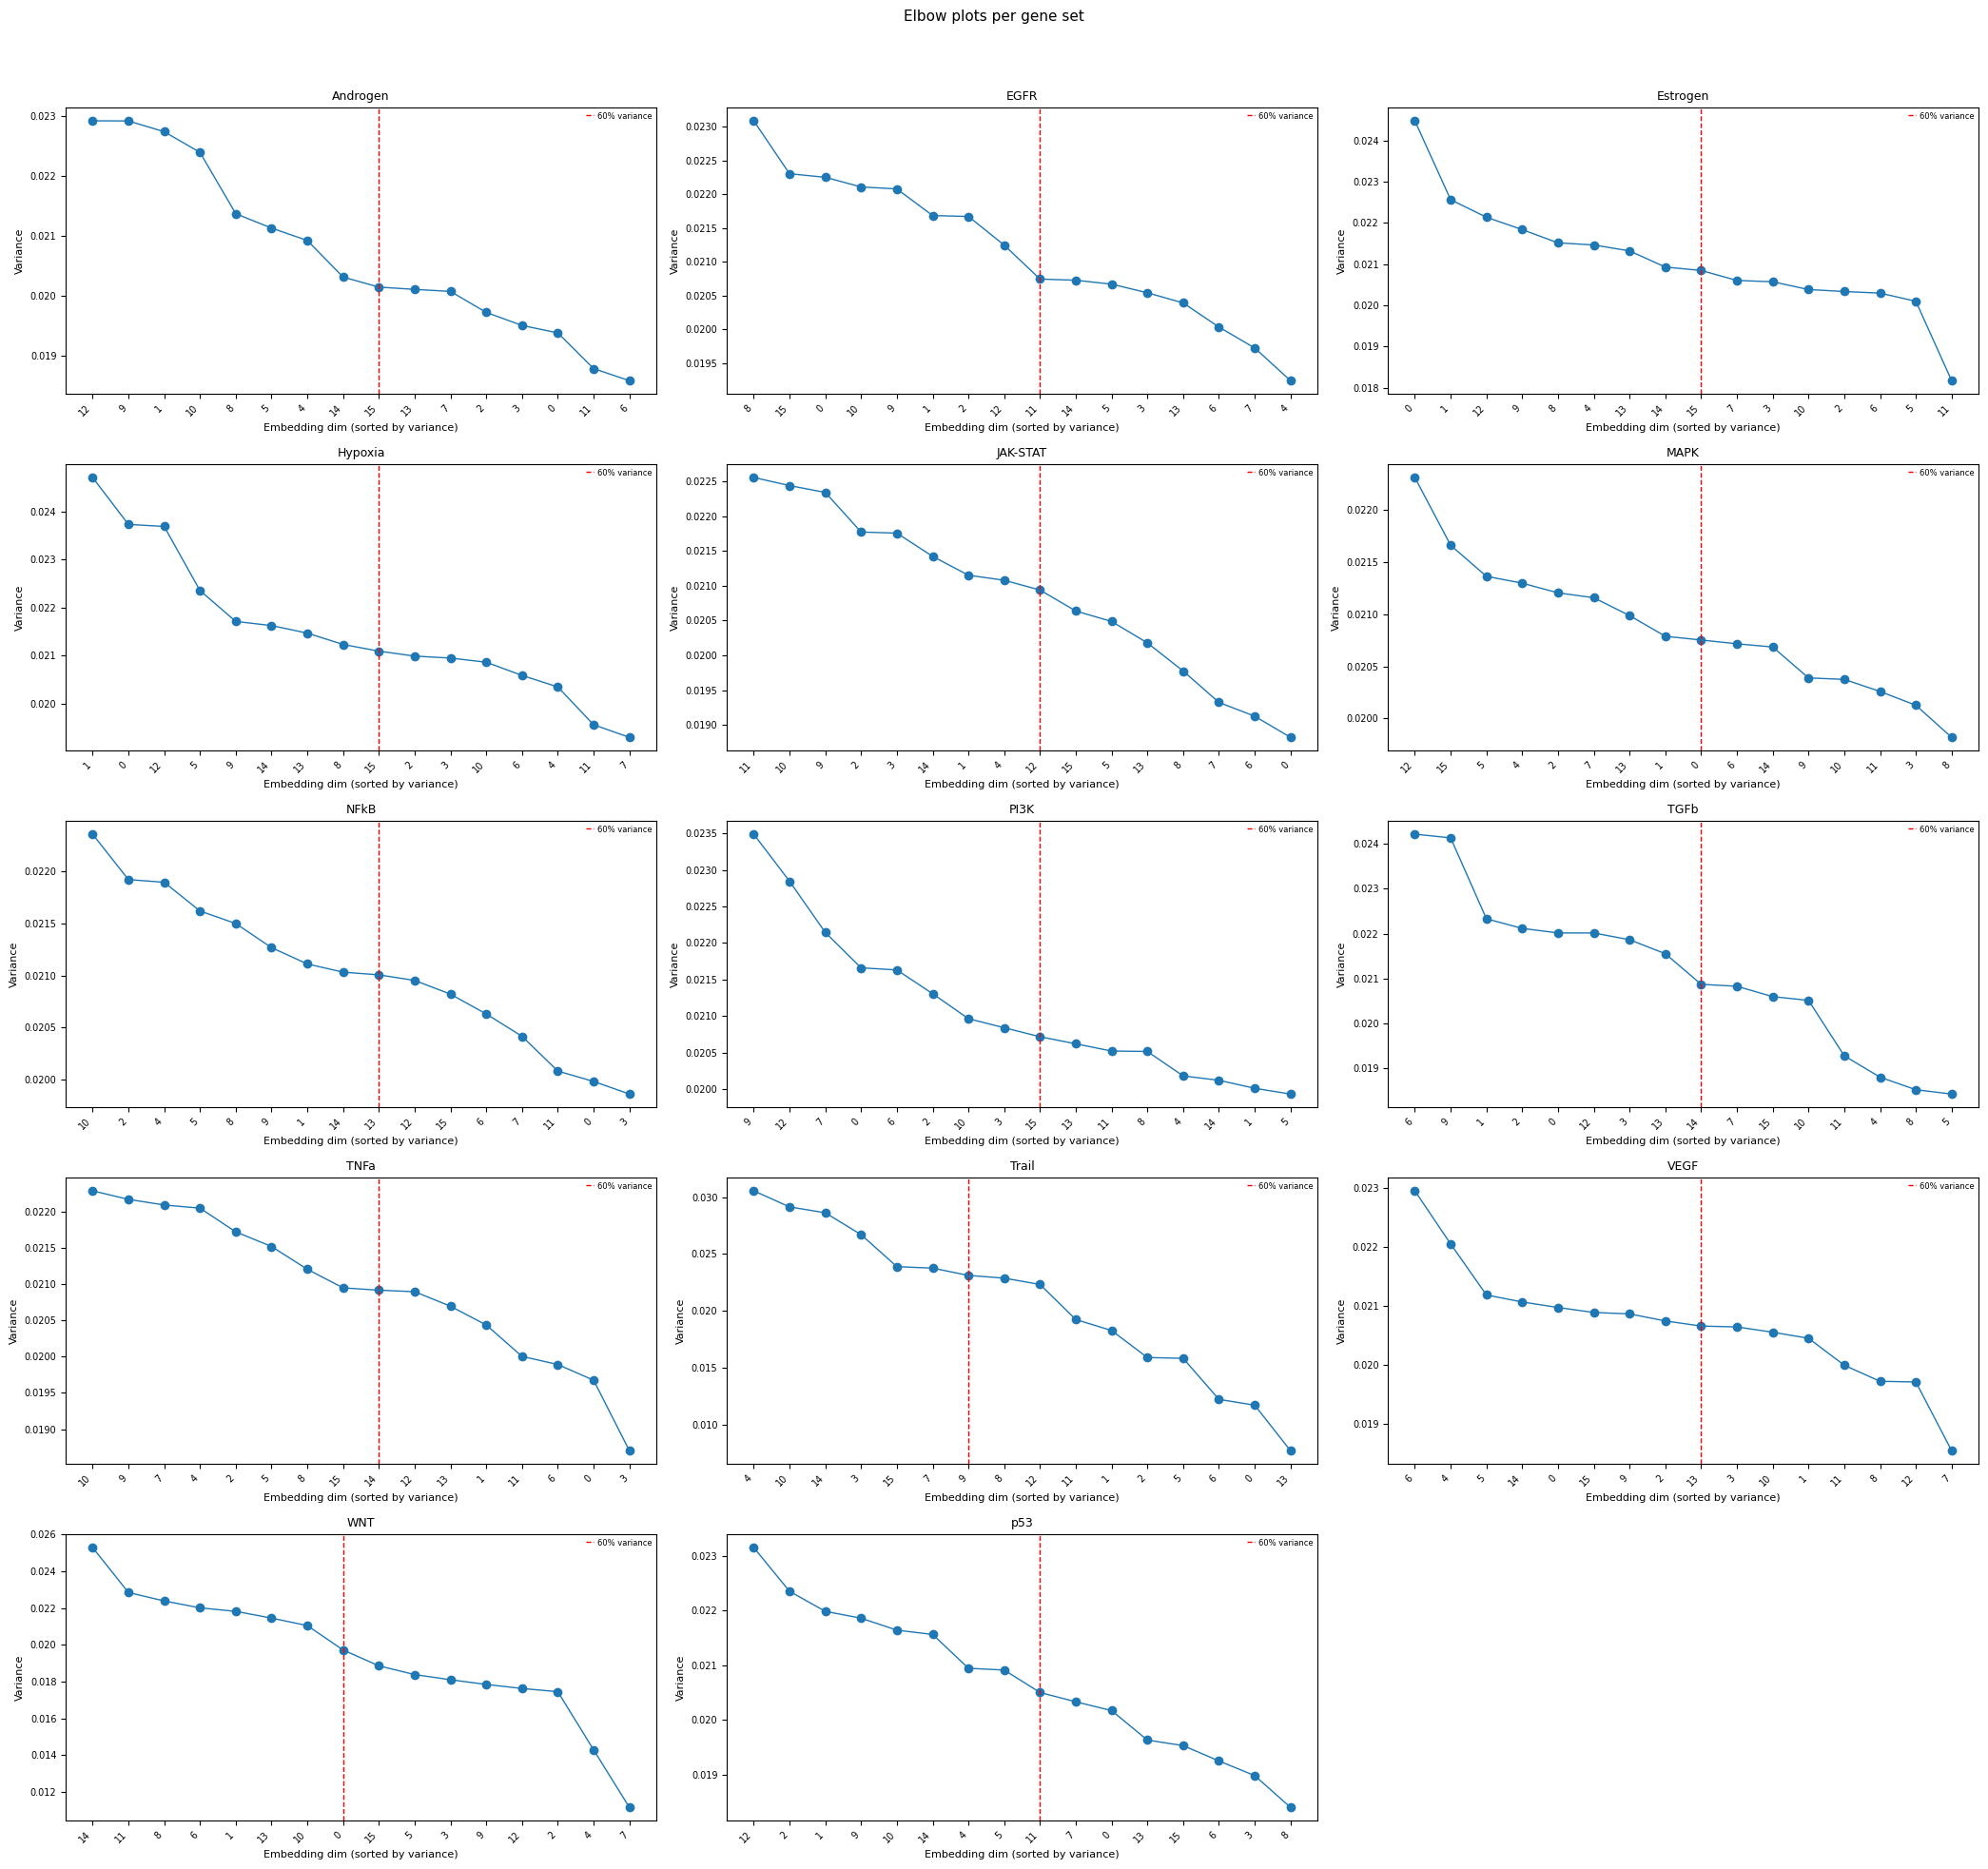

In [24]:
local_cov_df = gene_set_covariance(result, pathway_target_dict, varm_key = '_local_gene_loadings', plot = True)

In [ ]:
gobal_cov_df = gene_set_covariance(result, pathway_target_dict, varm_key = '_global_gene_loadings', plot = True)

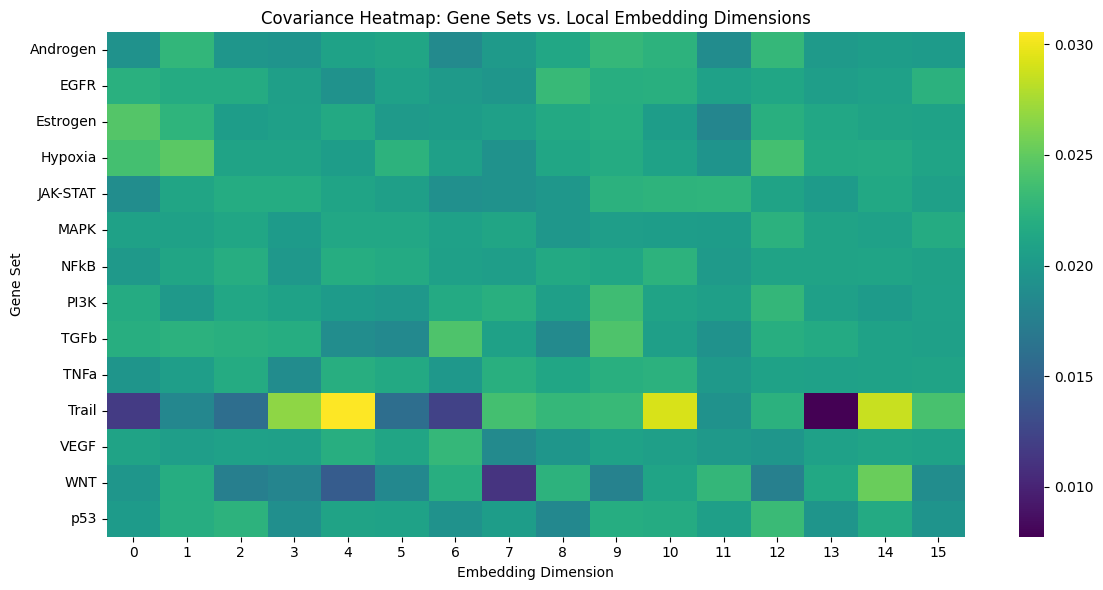

In [25]:
import matplotlib
#matplotlib.use('svg')  # Use SVG backend to avoid ft2font

import seaborn as sns
import matplotlib.pyplot as plt

# Pivot the data
heatmap_data = local_cov_df.reset_index().pivot(
    index="gene_set", columns="embedding_dimension", values="covariance"
)

# Plot
plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_data, annot=False, fmt=".2f", cmap="viridis")
plt.title("Covariance Heatmap: Gene Sets vs. Local Embedding Dimensions")
plt.xlabel("Embedding Dimension")
plt.ylabel("Gene Set")
plt.tight_layout()
plt.show()

In [ ]:
# Pivot the data
heatmap_data = gobal_cov_df.reset_index().pivot(
    index="gene_set", columns="embedding_dimension", values="covariance"
)

# Plot
plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_data, annot=False, fmt=".2f", cmap="viridis")
plt.title("Covariance Heatmap: Gene Sets vs. Global Embedding Dimensions")
plt.xlabel("Embedding Dimension")
plt.ylabel("Gene Set")
plt.tight_layout()
plt.show()

#### Select single fov for evaluation

In [26]:
nd_test = result[result.obs.query("slide == 'Run5211_S1' and fov == '12'").index, :]
nd_test.obs

,fov,Area,AspectRatio,CenterX_global_px,CenterY_global_px,Width,Height,Mean.MembraneStain,Max.MembraneStain,Mean.PanCK,...,globalX,globalY,sliding_window_square,sliding_window_h,sliding_window_v,_scvi_sample_key_0,_scvi_sample_key_1,_scvi_group_key,_cls_horizontal,_cls_vertical
47252,12,3457,1.00,25258.222222,147306.444444,73,73,786,11211,34,...,25258.222222,147306.444444,1_12_window_2,1_12_window_6,1_12_window_1,90,50,0,1.072575e-11,1.770488e-13
47253,12,3126,1.45,25368.222222,147313.444444,84,58,1513,13878,792,...,25368.222222,147313.444444,1_12_window_2,1_12_window_6,1_12_window_1,90,50,0,1.607116e-11,1.062642e-13
47254,12,1811,1.62,25683.222222,147323.444444,63,39,2069,12493,4211,...,25683.222222,147323.444444,1_12_window_2,1_12_window_6,1_12_window_1,90,50,0,7.652906e-12,1.348026e-13
47255,12,1388,1.22,25732.222222,147318.444444,60,49,4126,15201,6820,...,25732.222222,147318.444444,1_12_window_2,1_12_window_6,1_12_window_1,90,50,0,3.083368e-12,0.000000e+00
47256,12,2851,1.10,25974.222222,147306.444444,80,73,5876,16168,2157,...,25974.222222,147306.444444,1_12_window_2,1_12_window_6,1_12_window_1,90,50,0,3.596388e-21,9.400909e-12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52455,12,2853,1.40,25448.222222,143728.444444,73,52,132,1200,52,...,25448.222222,143728.444444,1_12_window_1,1_12_window_0,1_12_window_0,38,7,0,9.404771e-12,5.337273e-13
52456,12,1777,1.42,26518.222222,143734.444444,61,43,95,948,10,...,26518.222222,143734.444444,1_12_window_1,1_12_window_0,1_12_window_2,38,95,0,7.674951e-12,1.691582e-12
52457,12,2944,0.64,29365.222222,143734.444444,49,76,191,901,16,...,29365.222222,143734.444444,1_12_window_7,1_12_window_7,1_12_window_8,360,475,0,2.627131e-13,3.361945e-13
52458,12,3273,1.14,29421.222222,143725.444444,67,59,76,911,42,...,29421.222222,143725.444444,1_12_window_7,1_12_window_7,1_12_window_8,360,475,0,8.303153e-14,7.010025e-12


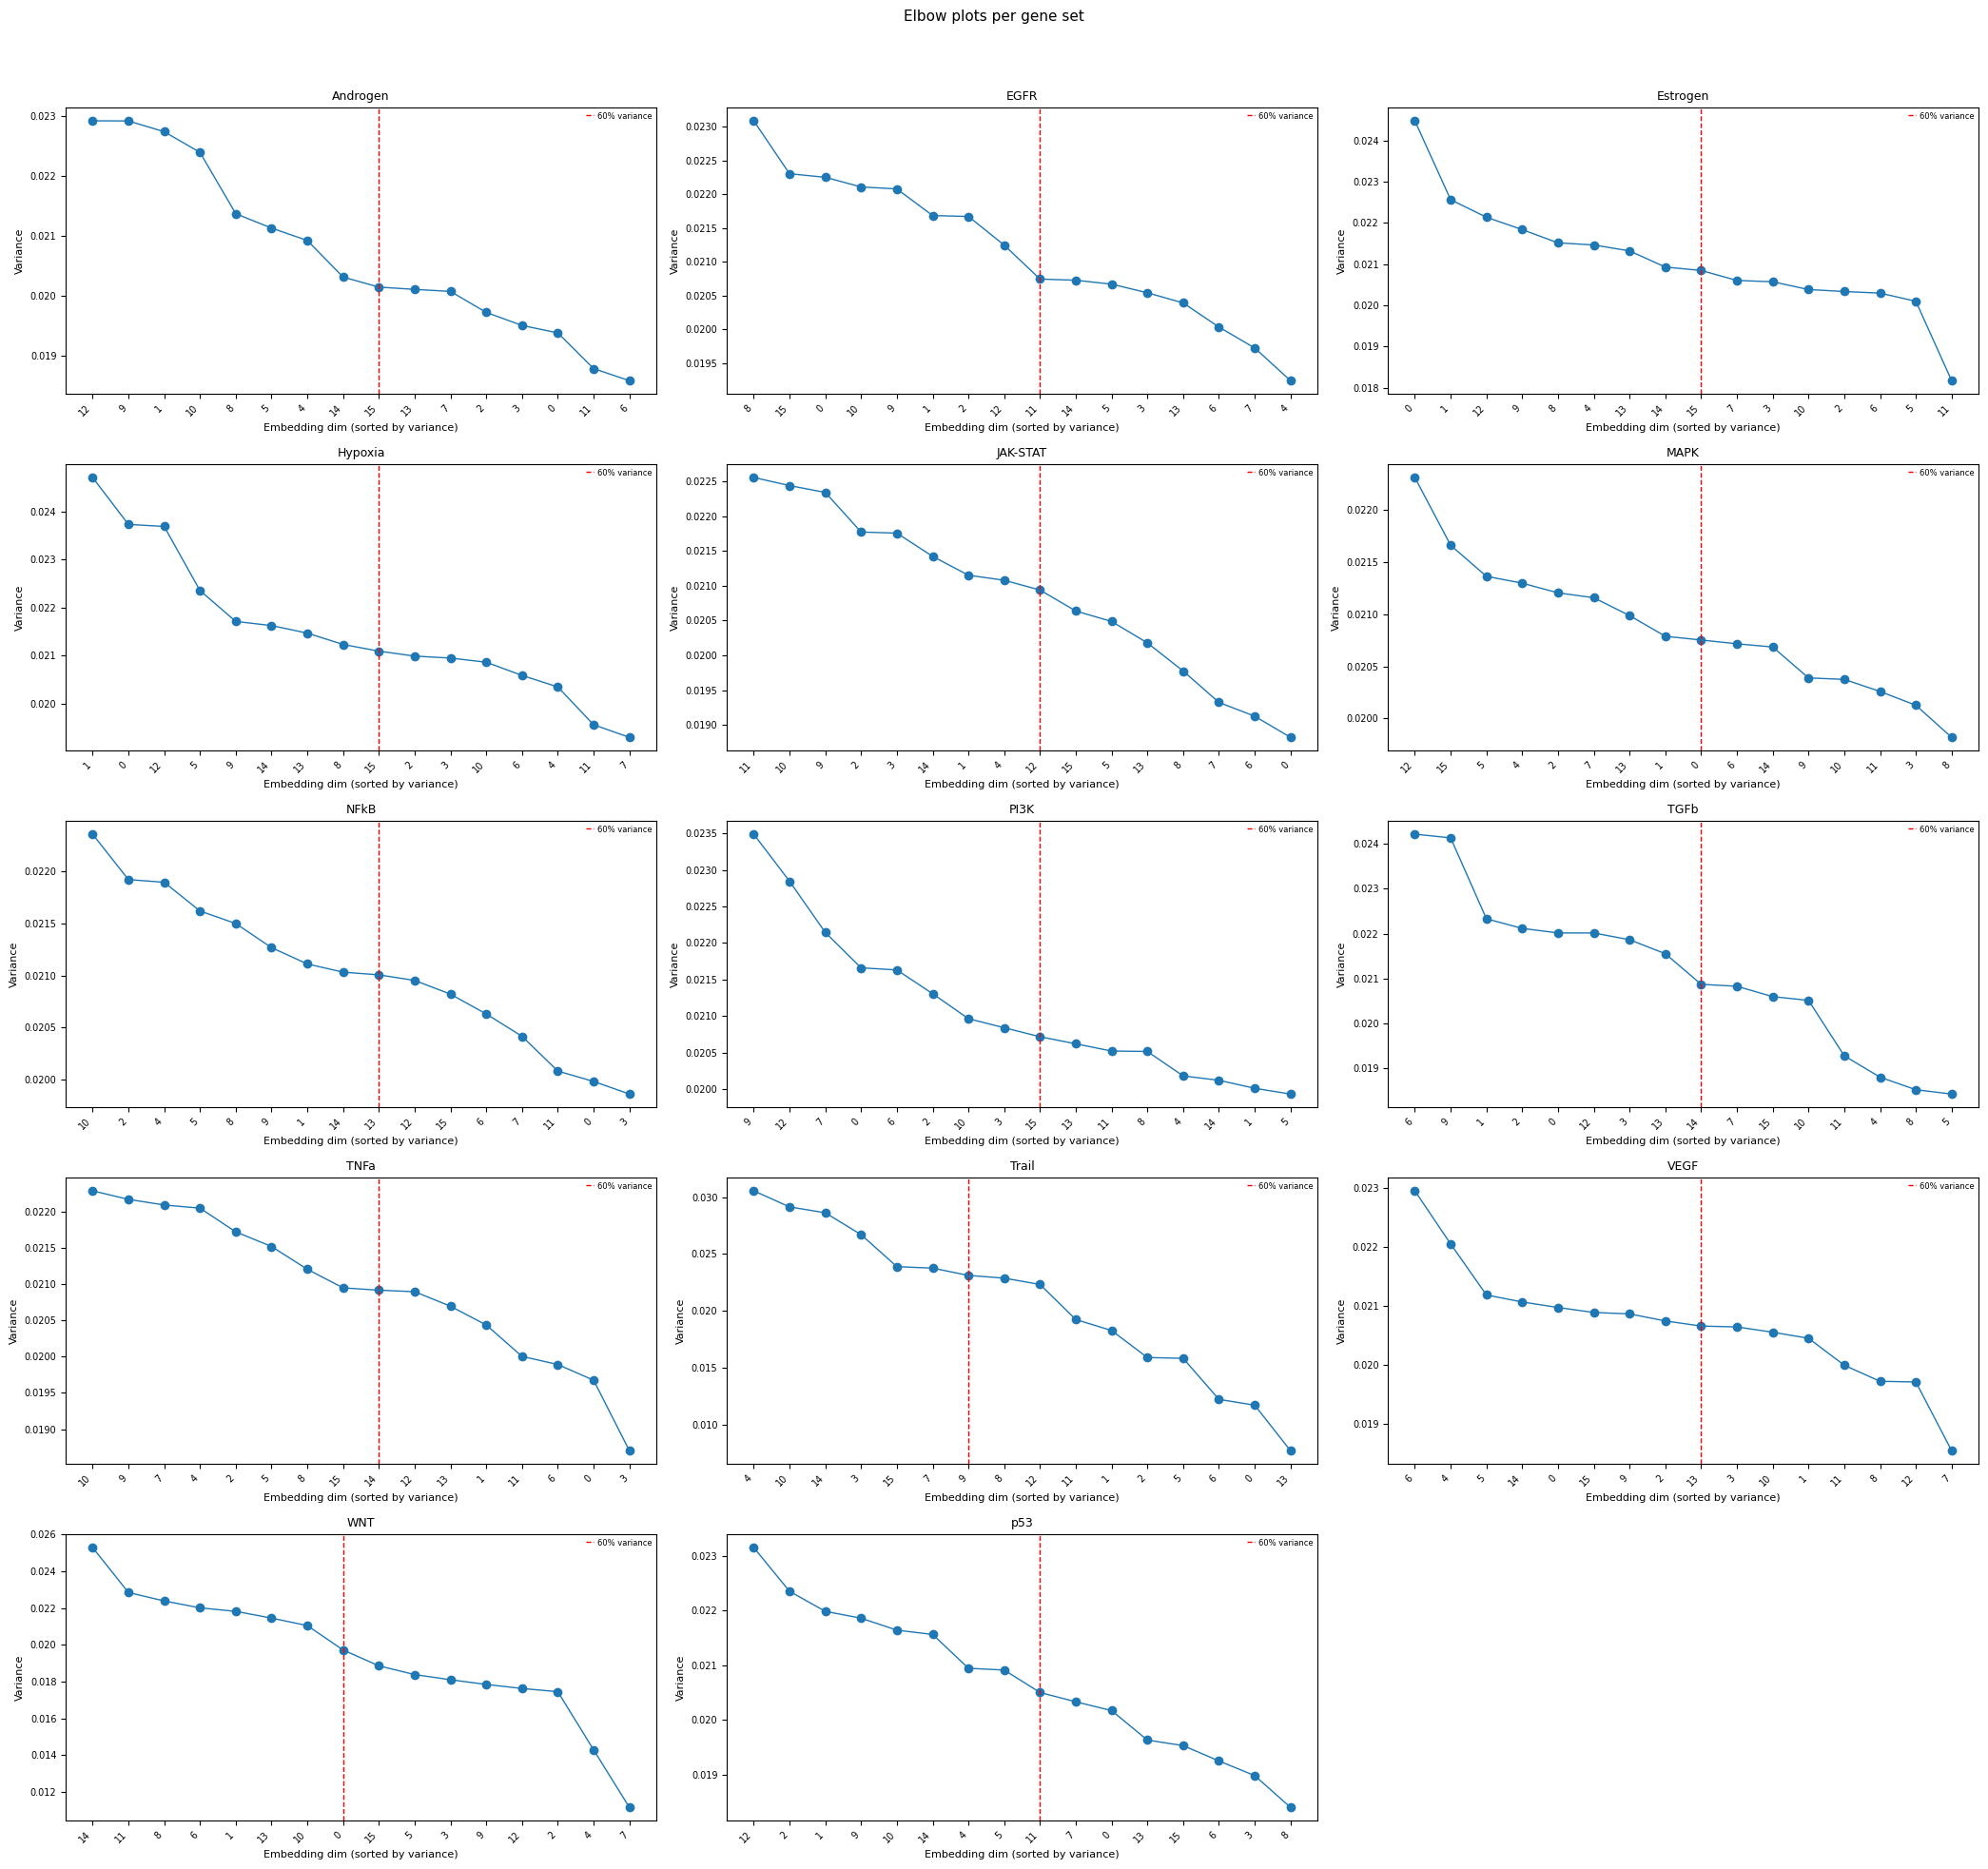

In [27]:
# Compute and display the results
local_cov_df_nd_test = gene_set_covariance(nd_test, pathway_target_dict, varm_key = '_local_gene_loadings', plot = True)

In [ ]:
# Compute and display the results
global_cov_df_nd_test = gene_set_covariance(nd_test, pathway_target_dict, varm_key = '_global_gene_loadings', plot = True)

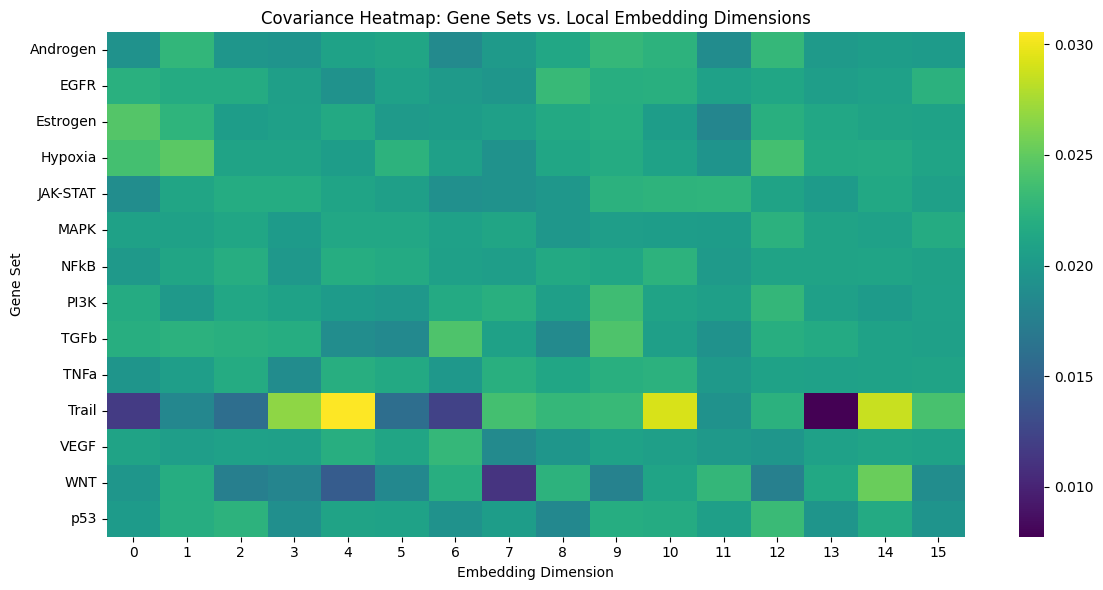

In [28]:
heatmap_data_l = local_cov_df_nd_test.reset_index().pivot(
    index="gene_set", columns="embedding_dimension", values="covariance"
)

# Plot
plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_data_l, annot=False, fmt=".2f", cmap="viridis")
plt.title("Covariance Heatmap: Gene Sets vs. Local Embedding Dimensions")
plt.xlabel("Embedding Dimension")
plt.ylabel("Gene Set")
plt.tight_layout()
plt.show()

In [ ]:
heatmap_data_g = global_cov_df_nd_test.reset_index().pivot(
    index="gene_set", columns="embedding_dimension", values="covariance"
)

# Plot
plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_data_g, annot=False, fmt=".2f", cmap="viridis")
plt.title("Covariance Heatmap: Gene Sets vs. Global Embedding Dimensions")
plt.xlabel("Embedding Dimension")
plt.ylabel("Gene Set")
plt.tight_layout()
plt.show()

In [29]:
heatmap_data_l

embedding_dimension,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
gene_set,,,,,,,,,,,,,,,,
Androgen,0.019374,0.022731,0.019715,0.019498,0.020916,0.021123,0.018577,0.020066,0.021363,0.022910,0.022386,0.018779,0.022913,0.020100,0.020305,0.020138
EGFR,0.022249,0.021683,0.021670,0.020541,0.019242,0.020669,0.020035,0.019726,0.023084,0.022077,0.022106,0.020744,0.021245,0.020391,0.020727,0.022301
Estrogen,0.024473,0.022560,0.020335,0.020571,0.021463,0.020098,0.020296,0.020603,0.021514,0.021835,0.020383,0.018173,0.022135,0.021319,0.020928,0.020845
Hypoxia,0.023729,0.024704,0.020994,0.020953,0.020353,0.022356,0.020593,0.019306,0.021235,0.021714,0.020867,0.019568,0.023687,0.021471,0.021628,0.021096
JAK-STAT,0.018822,0.021151,0.021771,0.021755,0.021079,0.020487,0.019125,0.019324,0.019774,0.022340,0.022438,0.022555,0.020938,0.020179,0.021421,0.020637
MAPK,0.020753,0.020789,0.021206,0.020127,0.021299,0.021365,0.020717,0.021160,0.019818,0.020390,0.020375,0.020259,0.022315,0.020988,0.020686,0.021663
NFkB,0.019981,0.021111,0.021923,0.019860,0.021897,0.021621,0.020630,0.020415,0.021500,0.021268,0.022360,0.020080,0.020953,0.021006,0.021032,0.020821
PI3K,0.021660,0.020013,0.021306,0.020841,0.020182,0.019934,0.021631,0.022143,0.020516,0.023488,0.020964,0.020522,0.022844,0.020621,0.020122,0.020718
TGFb,0.022016,0.022330,0.022116,0.021864,0.018804,0.018429,0.024214,0.020828,0.018525,0.024132,0.020515,0.019280,0.022014,0.021552,0.020871,0.020597


In [30]:
#z_global = (heatmap_data_g - heatmap_data_g.mean(axis=1).values[:, None]) / heatmap_data_g.std(axis=1).values[:, None]
z_local  = (heatmap_data_l - heatmap_data_l.mean(axis=1).values[:, None]) / heatmap_data_l.std(axis=1).values[:, None]

In [ ]:
pattern_diff = z_local - z_global

Text(0.5, 1.0, 'Local - Global: embedding dimension specificity')

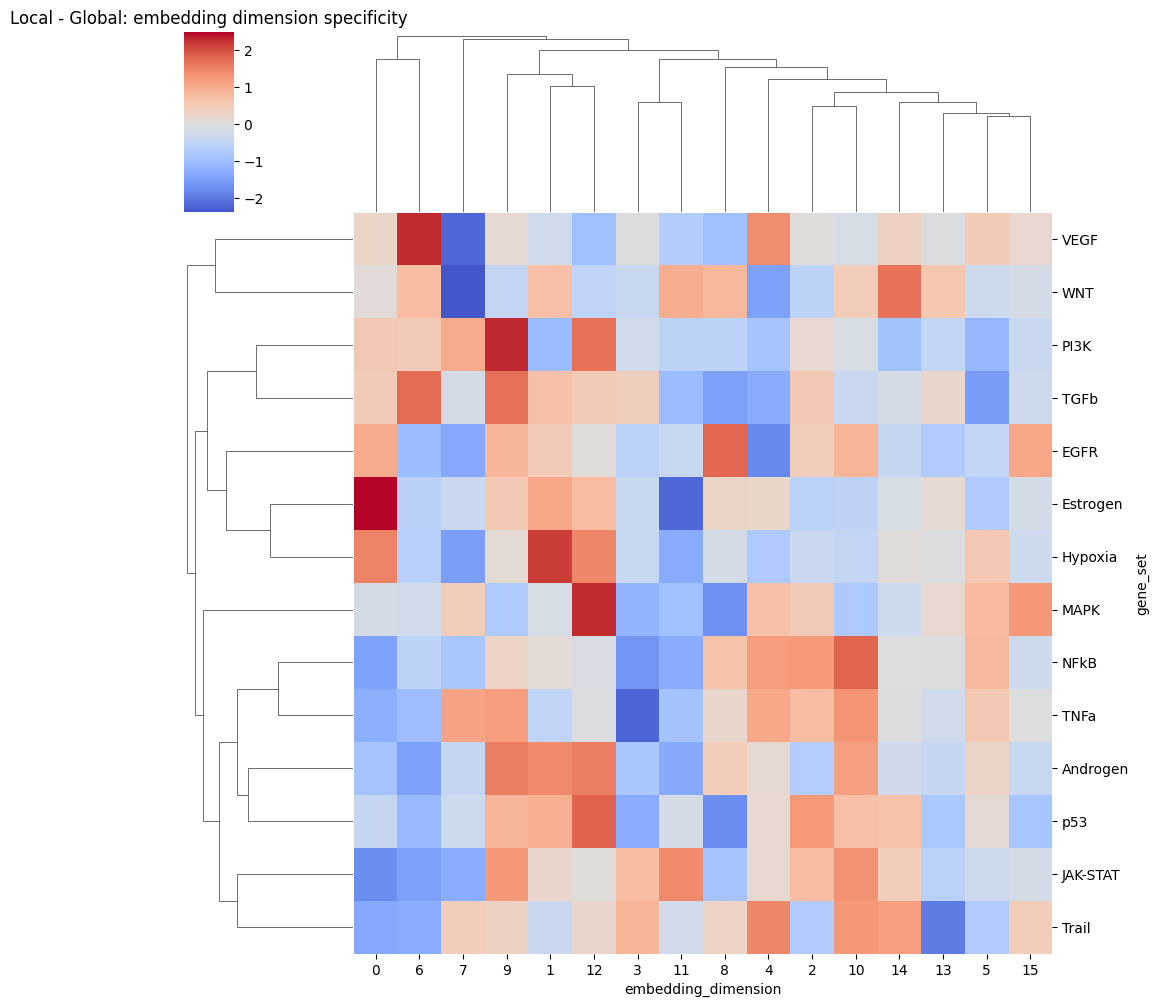

In [31]:
sns.clustermap(z_local, cmap="coolwarm", center=0)
plt.title("Local - Global: embedding dimension specificity")

In [32]:
from InterScale.evaluation import spatial_covariance_plot

{'Hypoxia': 1}

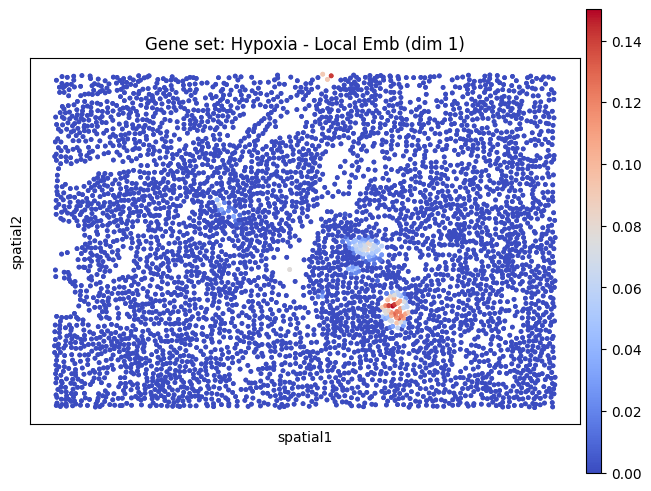

In [35]:
spatial_covariance_plot(
    nd_test,
    gene_sets = pathway_target_dict,
    int_length = "local",   # "local" or "global", 
    restrict_to = "Hypoxia",
    emb_dim = 1, 
    cmap = "coolwarm"
)

{'Estrogen': 0}

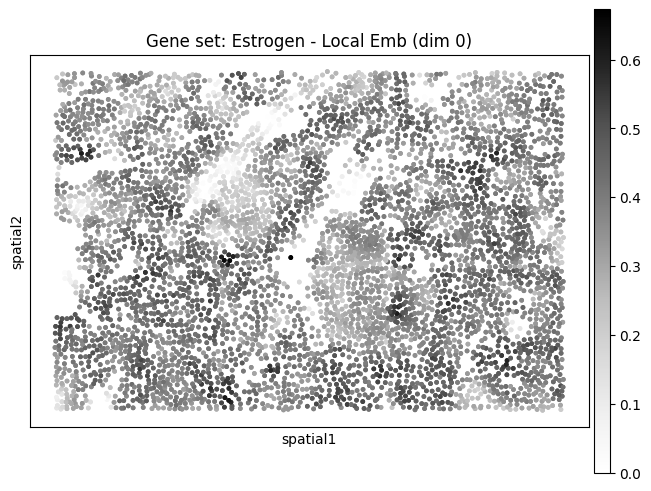

In [34]:
spatial_covariance_plot(
    nd_test,
    gene_sets = pathway_target_dict,
    int_length = "local",   # "local" or "global", 
    restrict_to = "Estrogen",
    emb_dim = 0, 
    cmap = "Greys"
)

### Cluster by distance 

In [3]:
test2 = sc.read_h5ad('/lustre/groups/shared/users/idr_icb/JDRF/refined_annotation/scIslet_integrated_refined_annotation.h5ad')
test2

AnnData object with n_obs × n_vars = 162259 × 44910
    obs: 'handle_anndata', 'lab', 'protocol', 'sample', 'stage', 'cell_type_authors', 'cell_type_lv1', 'protocol|lab|stage|sample', 'prep_n_counts', 'prep_n_genes_by_counts', 'prep_pct_counts_mt', 'prep_pct_counts_ribo', 'prep_pct_counts_bcr', 'prep_pct_counts_tcr', 'prep_score_mt', 'prep_score_ribo', 'prep_score_bcr', 'prep_score_tcr', 'prep_score_cc', 'prep_score_cc_s', 'prep_score_cc_g2m', 'prep_score_scanpy_cc_s', 'prep_score_scanpy_cc_g2m', 'prep_scanpy_cc_phase', 'prep_scanpy_sc_cycling_strength', 'qc_fail', 'qc_fail_reasons', 'cell_type_lv1||protocol|lab|stage|sample', 'leiden', 'size_factors', 'n_counts', 'log_counts', 'n_genes', 'log_genes', 'entropy', 'Beta_lineage_score', 'Alpha_lineage_score', 'EC_lineage_score', 'Endocrine_prog_early_score', 'Endocrine_prog_late_score', 'PEC_score', 'ASCL1_score', 'cycling_score', 'CCK_score', 'Delta_score', 'GAP43_score', 'leiden_res2', 'Beta_lineage_score_norm', 'Alpha_lineage_score_nor

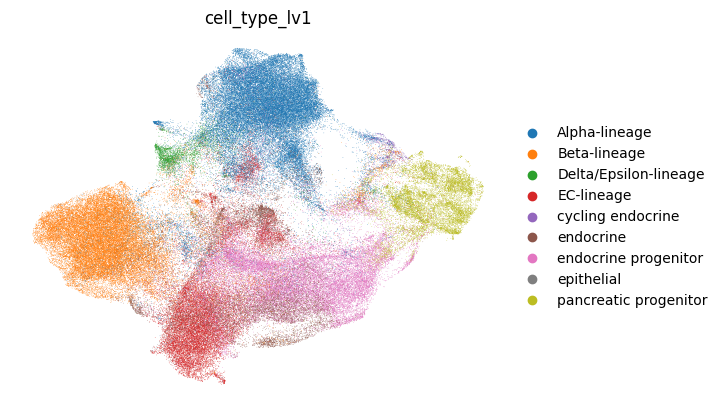

In [5]:
sc.pl.umap(test2, color='cell_type_lv1', frameon=False)

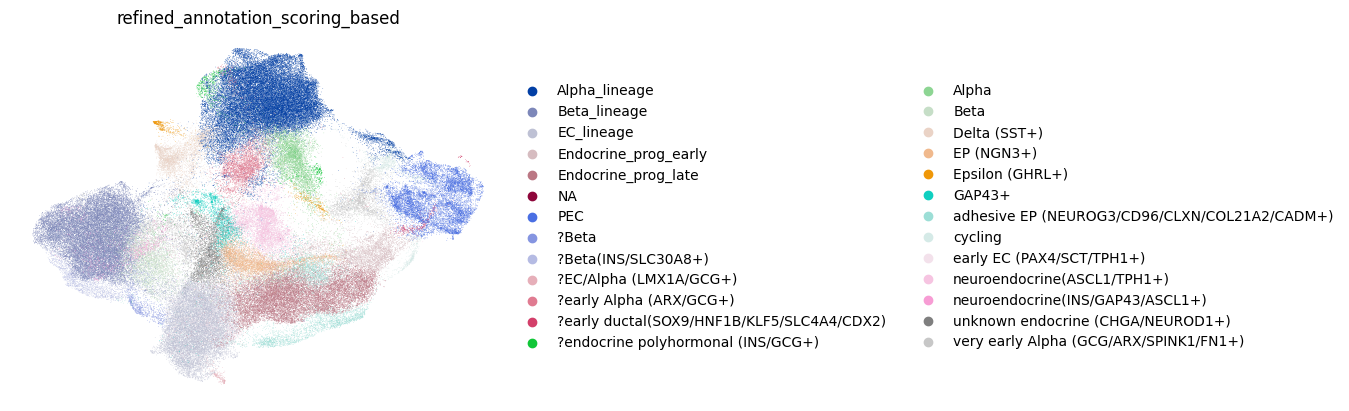

In [8]:
sc.pl.umap(test2, color='refined_annotation_scoring_based', frameon=False)

In [6]:
test = sc.read_h5ad('/lustre/groups/shared/users/idr_icb/Embryonic_Dev/HuEmDev/HFP_10x_proc_nodoub.h5ad')
test

AnnData object with n_obs × n_vars = 188488 × 31930
    obs: 'Sample', 'Age', 'ID', 'sample_id', 'n_counts', 'log_counts', 'n_genes', 'mt_frac', 'rb_frac', 'S_score', 'G2M_score', 'phase', 'size_factors', 'Age2', 'Batch', 'orig.ident', '...1', 'Well_ID', 'Well_coordinates', 'plate_ID', 'Subject_ID', 'Amp_batch_ID', 'Cell_barcode', 'Pool_barcode', 'cell_order', 'is_cell_control', 'total_features_by_counts', 'plate_id', 'outlier', 'integrated_snn_res.0.5', 'seurat_clusters', 'ids', 'ident', 'proliferation', 'batch', 'Enrich', 'leiden_scVI', 'annotation_2', 'celltype', 'annotation_1', 'BigGroups', 'CellFindR_update', 'n_counts_norm', 'log_counts_norm', 'n_counts_renorm', 'log_counts_renorm', 'scds_doublets', 'scds_scores', 'sdf_doublets', 'sdf_scores', 'df_doublets', 'df_scores', 'scrub_doublets', 'scrub_scores', 'dd_doublets', 'dd_scores', 'doublet_calls', 'doublets', 'louvain_scVI_nodoub', 'annotation_nodoub', 'annotation_nodoub_2', 'Age1', 'annotation_nodoub_broad', 'is_epithelial'
   

In [7]:
test.obs['annotation_nodoub'].cat.categories

Index(['Acinar', 'Alpha', 'Beta', 'Delta', 'Ductal', 'EP', 'Endothelial',
       'Epsilon', 'Hepato', 'Immune', 'MPC', 'Mesenchymal', 'Neuronal', 'PP',
       'Ribo'],
      dtype='object')

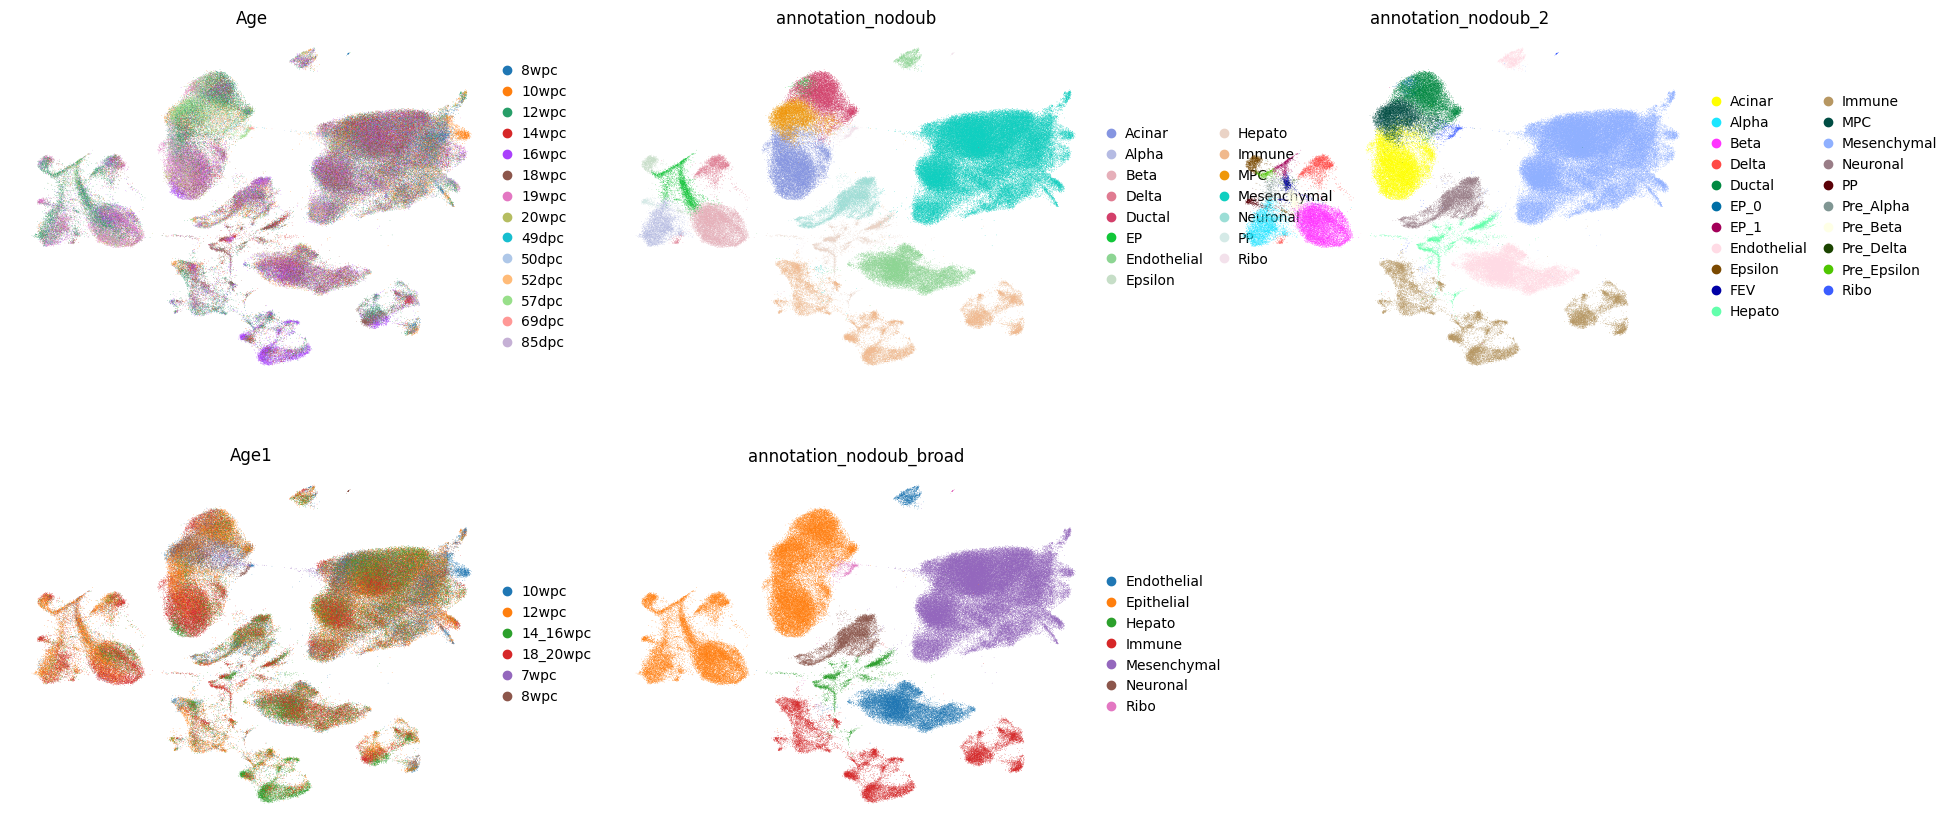

In [38]:
sc.pl.embedding(test, color=['Age','annotation_nodoub','annotation_nodoub_2', 'Age1', 'annotation_nodoub_broad'], 
                ncols=3, basis='X_scVI_umap', frameon=False)

In [39]:
gene_name = 'SHH'
threshold = 50

if gene_name in ctrl_test.var_names:
    gene_expression = ctrl_test[:, gene_name].X
    if not isinstance(gene_expression, np.ndarray):
        gene_expression = gene_expression.toarray().flatten()  # For sparse matrices
    else:
        gene_expression = gene_expression.flatten()

    # Annotate cells in the obs field based on the expression threshold
    ctrl_test.obs[f'{gene_name}_status'] = np.where(gene_expression >= threshold, f'{gene_name}+', f'{gene_name}-')
else:
    print(f"Gene '{gene_name}' not found in adata.var_names.")


In [ ]:
!pip install squidpy

In [40]:
import squidpy as sq

In [ ]:
!pip install numpy==1.26.4 --force-reinstall

/home/aih/sara.jimenez/miniconda3/envs/interscale/lib/python3.11/site-packages/squidpy/pl/_spatial_utils.py:976: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


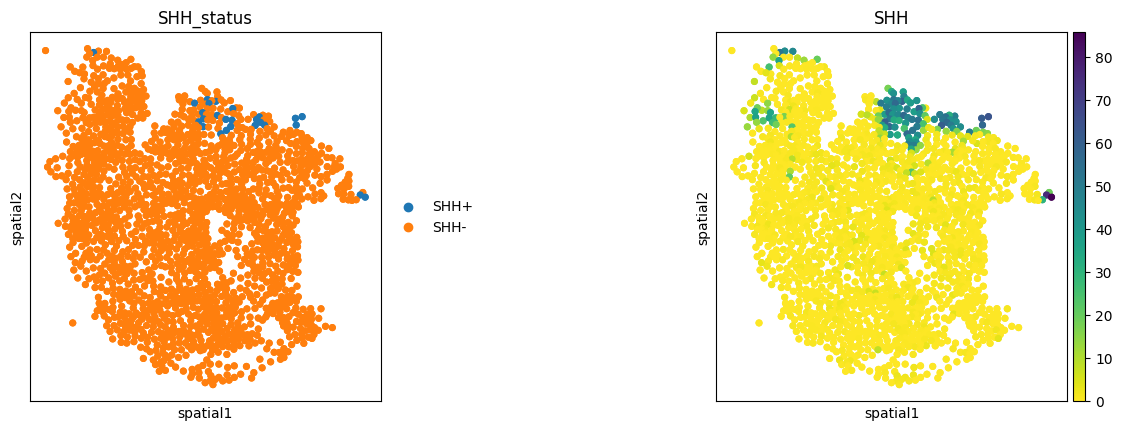

In [41]:
sq.pl.spatial_scatter(ctrl_test, 
                      color = ['SHH_status','SHH'],
                      cmap = 'viridis_r',
                      shape= None
                     )

In [42]:
# Coordinates
coords = ctrl_test.obsm["spatial"]
shh_coords = coords[ctrl_test.obs["SHH_status"] == "SHH+"]

# Compute distance to nearest SHH+ cell
from scipy.spatial import cKDTree
tree = cKDTree(shh_coords)
dist, _ = tree.query(coords, k=1)
ctrl_test.obs["dist_to_SHH+"] = dist

# Cluster cells based on distance
sc.pp.neighbors(ctrl_test, use_rep=None, n_neighbors=10)
ctrl_test.obs["distance_cluster"] = np.digitize(ctrl_test.obs["dist_to_SHH+"], bins=[10, 20, 30])  # arbitrary cutoffs

/home/aih/sara.jimenez/miniconda3/envs/interscale/lib/python3.11/site-packages/scanpy/neighbors/__init__.py:577: UserWarning: You’re trying to run this on 88 dimensions of `.X`, if you really want this, set `use_rep='X'`.
         Falling back to preprocessing with `sc.pp.pca` and default params.
  x = _choose_representation(self._adata, use_rep=use_rep, n_pcs=n_pcs)


In [43]:
dist = ctrl_test.obs["dist_to_SHH+"].to_numpy()

n_bins = 4
edges = np.quantile(dist, np.linspace(0, 1, n_bins + 1))
labels = [f"ring_{i+1}" for i in range(len(edges)-1)]

cats = pd.cut(dist, bins=edges, labels=labels, include_lowest=True, duplicates="drop")
# directly ensure it's ordered
cats = pd.Categorical(cats, categories=labels, ordered=True)

ctrl_test.obs["SHH_dist_ring"] = cats

/home/aih/sara.jimenez/miniconda3/envs/interscale/lib/python3.11/site-packages/squidpy/pl/_spatial_utils.py:976: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(
/home/aih/sara.jimenez/miniconda3/envs/interscale/lib/python3.11/site-packages/squidpy/pl/_spatial_utils.py:976: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


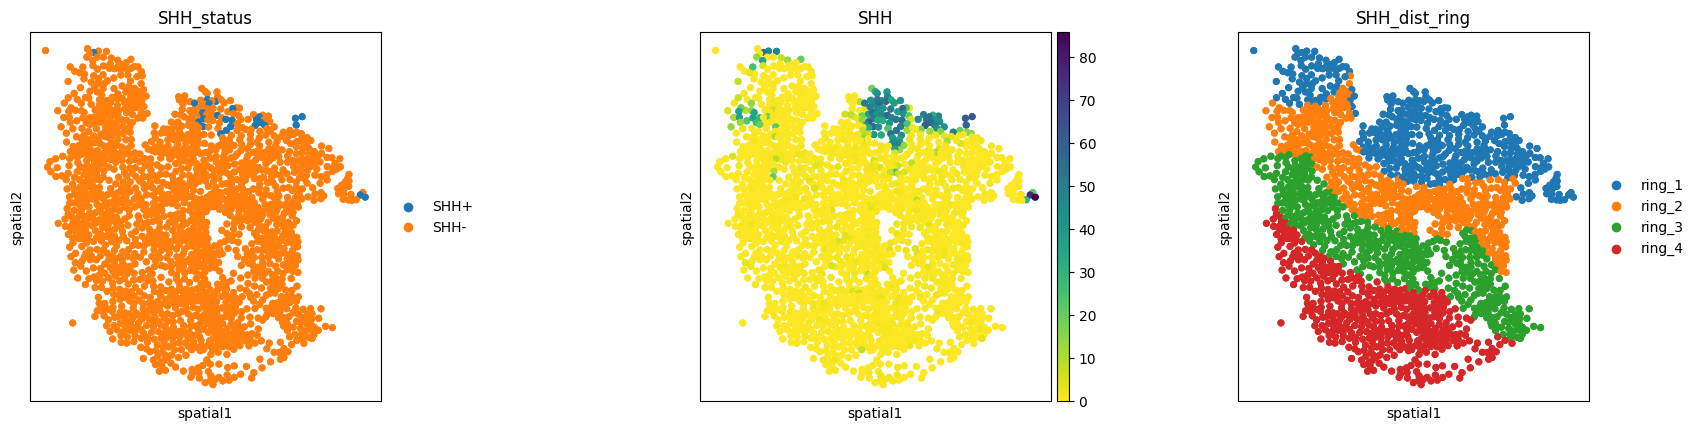

In [44]:
sq.pl.spatial_scatter(ctrl_test, 
                      color = ['SHH_status','SHH','SHH_dist_ring'],
                      cmap = 'viridis_r',
                      shape= None
                     )

In [106]:
ctrl_test.obsm['_local_emb'].shape

(1772, 16)

/tmp/ipykernel_1575098/1689572529.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  M = (df.groupby("ring")[cols]
/tmp/ipykernel_1575098/1689572529.py:21: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  M = (M - M.mean(axis=0)) / (M.std(axis=0).replace(0, np.nan))
/tmp/ipykernel_1575098/1689572529.py:22: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  M =

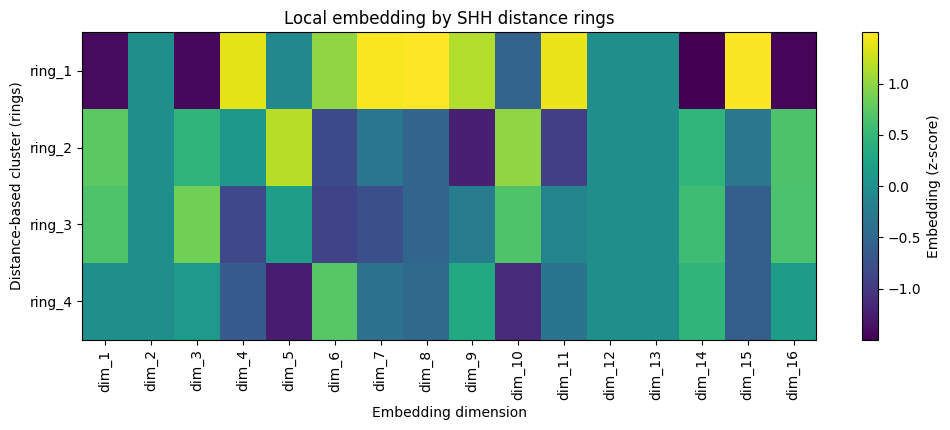

In [45]:
# --- inputs
rings = ctrl_test.obs["SHH_dist_ring"].astype("category")
emb = ctrl_test.obsm["_local_emb"]  # shape: (n_cells, d)
d = emb.shape[1]

# --- make a DataFrame for easy grouping
cols = [f"dim_{i+1}" for i in range(d)]
df = pd.DataFrame(emb, columns=cols)
df["ring"] = rings.values

# ensure ordered rows by categorical order
ordered_rings = list(rings.cat.categories)

# --- aggregate: mean per ring (you can swap to .median() if you prefer)
M = (df.groupby("ring")[cols]
       .mean()
       .reindex(ordered_rings))

# --- optional: z-score each column so colors are comparable across dims
# comment this block if you prefer raw means
M = (M - M.mean(axis=0)) / (M.std(axis=0).replace(0, np.nan))
M = M.fillna(0.0)

# --- plot with matplotlib
fig_h = 0.6 * len(ordered_rings) + 2
fig_w = min(0.45 * d + 3, 18)
fig, ax = plt.subplots(figsize=(fig_w, fig_h))

im = ax.imshow(M.values, aspect="auto", interpolation="nearest")
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Embedding (z-score)")

# ticks/labels
ax.set_yticks(range(len(ordered_rings)))
ax.set_yticklabels(ordered_rings)

# For many dims, thin x tick labels
step = 1 if d <= 30 else (2 if d <= 60 else 5)
ax.set_xticks(range(0, d, step))
ax.set_xticklabels([cols[i] for i in range(0, d, step)], rotation=90)

ax.set_xlabel("Embedding dimension")
ax.set_ylabel("Distance-based cluster (rings)")
ax.set_title("Local embedding by SHH distance rings")

plt.tight_layout()
plt.show()